In [1]:
import os

print("=== /kaggle/input ===")
print(os.listdir('/kaggle/input'))

print("\n=== celeba-dataset ===")
print(os.listdir('/kaggle/input/datasets/jessicali9530/celeba-dataset'))


=== /kaggle/input ===
['datasets']

=== celeba-dataset ===
['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [2]:
import os
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from collections import Counter
import pandas as pd





# ====================== ======================
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_SIZE = 128
CENTER_CROP_SIZE = 178
BATCH_SIZE = 256 # hardcoded but dont worry 
NUM_WORKERS = 4
RANDOM_SEED = 42
OUTPUT_DIR = '/kaggle/working'

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f"  Device: {DEVICE}")
print(f"  Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")

# ====================== مسیرها ======================
CELEBA_BASE = '/kaggle/input/datasets/jessicali9530/celeba-dataset'
ATTR_FILE = os.path.join(CELEBA_BASE, 'list_attr_celeba.csv')

img_candidate_1 = os.path.join(CELEBA_BASE, 'img_align_celeba', 'img_align_celeba')
img_candidate_2 = os.path.join(CELEBA_BASE, 'img_align_celeba')

if os.path.isdir(img_candidate_1):
    sample_files = os.listdir(img_candidate_1)[:5]
    if any(f.endswith('.jpg') for f in sample_files):
        IMG_DIR = img_candidate_1
    else:
        IMG_DIR = img_candidate_2
elif os.path.isdir(img_candidate_2):
    IMG_DIR = img_candidate_2
else:
    raise FileNotFoundError(" پوشه تصاویر پیدا نشد!")

print(f"\n  IMG_DIR  : {IMG_DIR}")
print(f"  ATTR_FILE: {ATTR_FILE}")

num_images = len([f for f in os.listdir(IMG_DIR) if f.endswith('.jpg')])
print(f"  Number of images: {num_images:,}")


  Device: cuda
  Image size: 128×128
  Batch size: 256

  IMG_DIR  : /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
  ATTR_FILE: /kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv
  Number of images: 202,599


In [3]:
# ====================================================================
# ====================================================================

class CelebAKaggle(Dataset):
   
    
    def __init__(self, img_dir, attr_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        
        print(" Loading attributes CSV...")
        df = pd.read_csv(attr_file)
        
        self.filenames = df.iloc[:, 0].tolist()
        self.attr_names = list(df.columns[1:])
        
        attr_values = df.iloc[:, 1:].values.astype(np.int64)
        attr_values = np.where(attr_values == -1, 0, attr_values)
        self.attributes = torch.tensor(attr_values, dtype=torch.long)
        
        print(f" Loaded: {len(self.filenames):,} images, {len(self.attr_names)} attributes")
        print(f"   Sample attributes: {self.attr_names[:5]}")
    
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.filenames[idx])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, self.attributes[idx]


# ====================== Transform ======================
train_transform = transforms.Compose([
    transforms.CenterCrop(CENTER_CROP_SIZE),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ======================  ======================
celeba_dataset = CelebAKaggle(
    img_dir=IMG_DIR,
    attr_file=ATTR_FILE,
    transform=train_transform
)


 Loading attributes CSV...
 Loaded: 202,599 images, 40 attributes
   Sample attributes: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald']


In [4]:
# ====================================================================
# فیلتر و توازن: Black_Hair و Brown_Hair
# ====================================================================

print("=" * 60)
print("filter data")
print("=" * 60)

attr_names = celeba_dataset.attr_names
all_attrs = celeba_dataset.attributes

# پیدا کردن ایندکس ویژگی‌ها
black_idx = attr_names.index('Black_Hair')
brown_idx = attr_names.index('Brown_Hair')
print(f"Black_Hair attribute index: {black_idx}")
print(f"Brown_Hair attribute index: {brown_idx}")

# دسته‌بندی تصاویر
only_black = []
only_brown = []
both = []

for i in range(len(celeba_dataset)):
    has_black = all_attrs[i][black_idx].item() == 1
    has_brown = all_attrs[i][brown_idx].item() == 1
    
    if has_black and has_brown:
        both.append(i)
    elif has_black:
        only_black.append(i)
    elif has_brown:
        only_brown.append(i)

print(f"\n stat:")
print(f"  Only Black_Hair : {len(only_black):>8,}")
print(f"  Only Brown_Hair : {len(only_brown):>8,}")
print(f"  Both            : {len(both):>8,}")
print(f"  ─────────────────────────")
print(f"  Total relevant  : {len(only_black) + len(only_brown) + len(both):>8,}")

# محاسبه تعداد مؤثر
eff_black = only_black + both
eff_brown = only_brown + both

print(f"\n  Effective Black_Hair: {len(eff_black):,}")
print(f"  Effective Brown_Hair: {len(eff_brown):,}")

# توازن
min_count = min(len(eff_black), len(eff_brown))
print(f"  Target count (min): {min_count:,}")

sampled_black = list(np.random.choice(eff_black, size=min_count, replace=False))
sampled_brown = list(np.random.choice(eff_brown, size=min_count, replace=False))

selected_indices = sorted(list(set(sampled_black + sampled_brown)))

labels_map = {}
for idx in selected_indices:
    hb = all_attrs[idx][black_idx].item() == 1
    hr = all_attrs[idx][brown_idx].item() == 1
    if hb and hr:
        labels_map[idx] = 2   # Both
    elif hb:
        labels_map[idx] = 0   # Black
    else:
        labels_map[idx] = 1   # Brown

lc = Counter(labels_map.values())
final_black = lc.get(0, 0) + lc.get(2, 0)
final_brown = lc.get(1, 0) + lc.get(2, 0)
ratio = min(final_black, final_brown) / max(final_black, final_brown) if max(final_black, final_brown) > 0 else 0

print(f"\n :")
print(f"  Black_Hair (0) : {lc.get(0, 0):>8,}")
print(f"  Brown_Hair (1) : {lc.get(1, 0):>8,}")
print(f"  Both       (2) : {lc.get(2, 0):>8,}")
print(f"  ─────────────────────────")
print(f"  Total selected : {len(selected_indices):>8,}")
print(f"\n  Effective Black: {final_black:,}")
print(f"  Effective Brown: {final_brown:,}")
print(f"  Balance ratio  : {ratio:.4f} ")


filter data
Black_Hair attribute index: 8
Brown_Hair attribute index: 11

 stat:
  Only Black_Hair :   47,336
  Only Brown_Hair :   40,436
  Both            :    1,136
  ─────────────────────────
  Total relevant  :   88,908

  Effective Black_Hair: 48,472
  Effective Brown_Hair: 41,572
  Target count (min): 41,572

 :
  Black_Hair (0) :   40,593
  Brown_Hair (1) :   40,436
  Both       (2) :    1,136
  ─────────────────────────
  Total selected :   82,165

  Effective Black: 41,729
  Effective Brown: 41,572
  Balance ratio  : 0.9962 


In [5]:
# ====================================================================
# ساخت Dataset فیلترشده و DataLoader
# ====================================================================

class FilteredCelebA(Dataset):
    def __init__(self, base_dataset, indices, labels_map):
        self.base = base_dataset
        self.indices = indices
        self.labels_map = labels_map
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, full_attrs = self.base[real_idx]
        label = self.labels_map[real_idx]
        return image, label


filtered_dataset = FilteredCelebA(celeba_dataset, selected_indices, labels_map)

train_loader = DataLoader(
    filtered_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if DEVICE.type == 'cuda' else False,
    drop_last=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None
)

print(f" Filtered Dataset : {len(filtered_dataset):,} images")
print(f" DataLoader       : {len(train_loader)} batches")
print(f" atch size       : {BATCH_SIZE}")
print(f" drop_last        : True")


 Filtered Dataset : 82,165 images
 DataLoader       : 320 batches
 atch size       : 256
 drop_last        : True


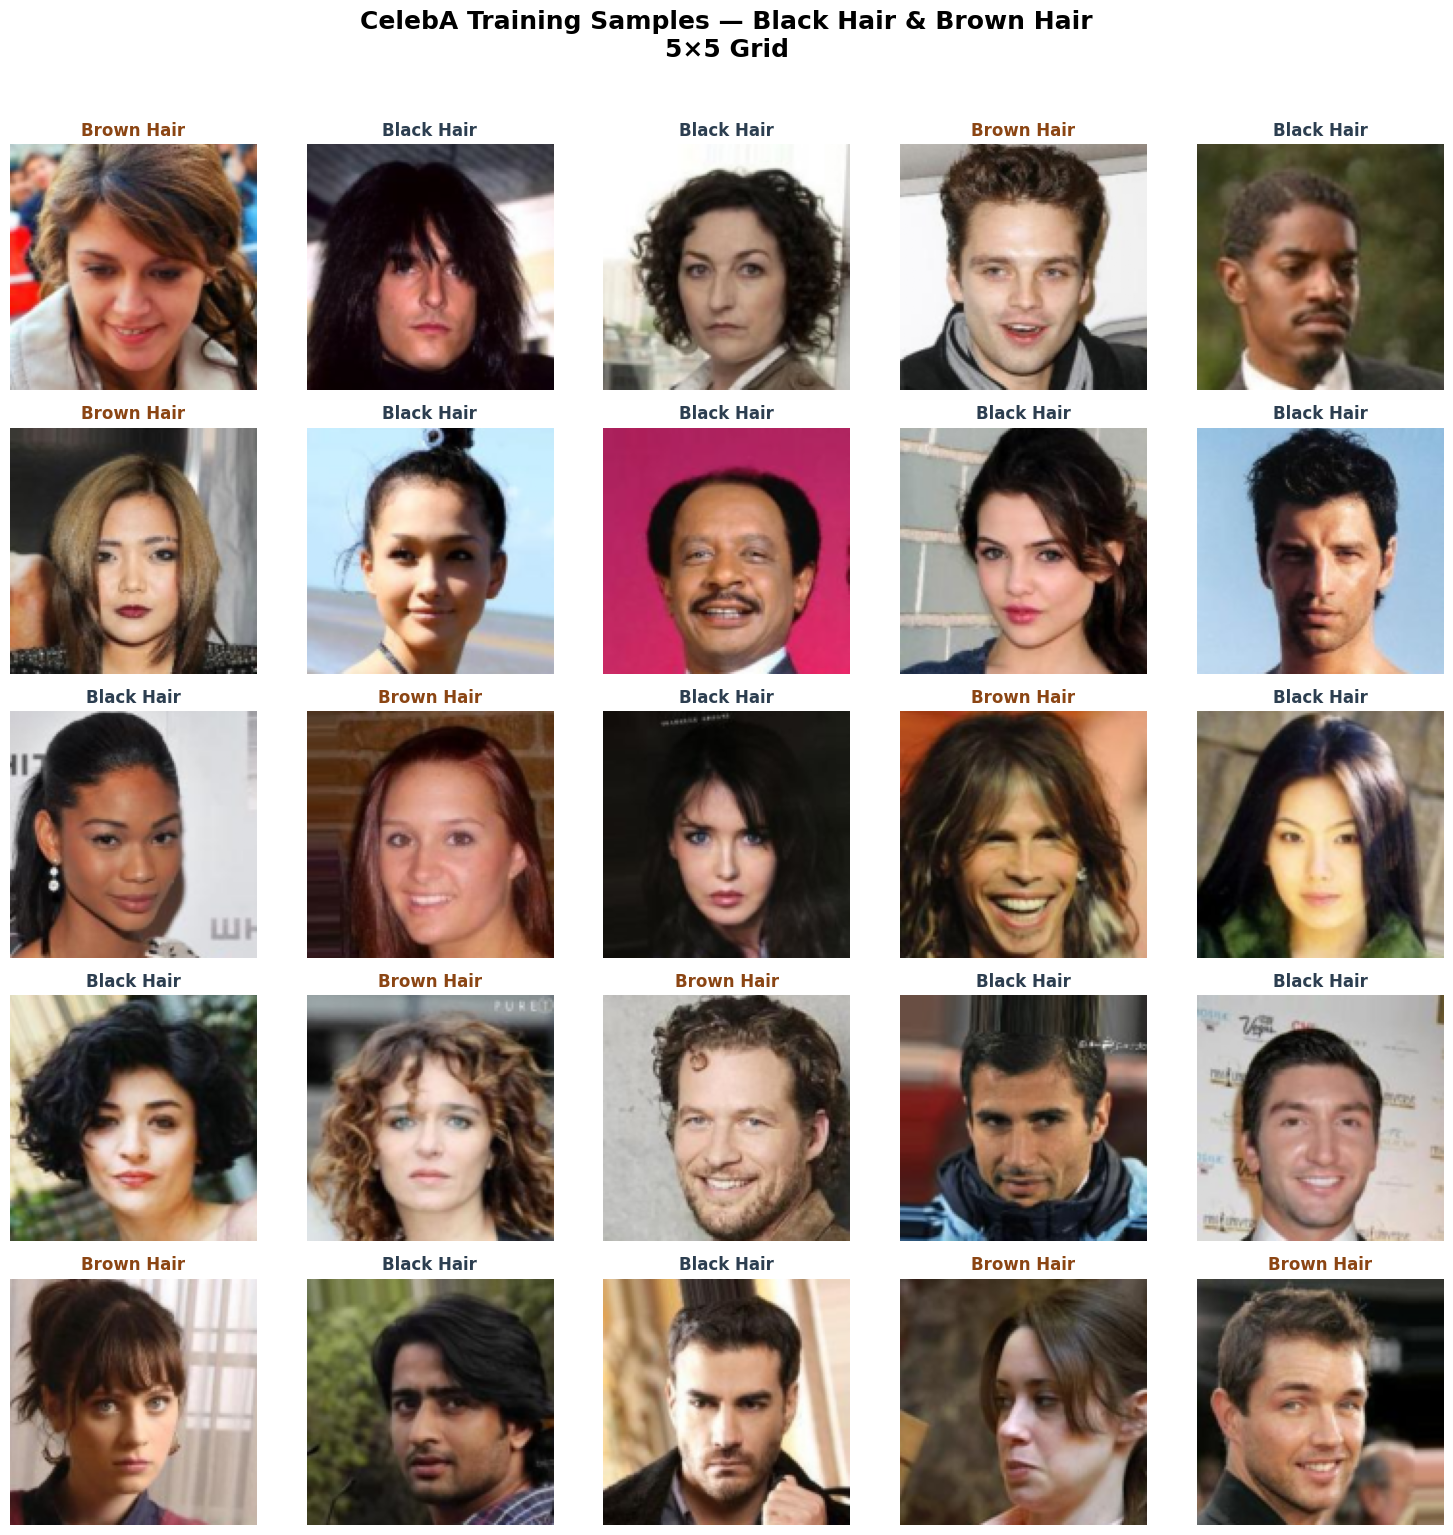

 Saved: /kaggle/working/celeba_grid_5x5.png


In [6]:
# ====================================================================
#   5×5
# ====================================================================

def denormalize(tensor):
    """[-1, 1] → [0, 1]"""
    return tensor * 0.5 + 0.5

# گرفتن یک بچ
images, labels = next(iter(train_loader))
images_show = denormalize(images[:25])

label_names = {0: 'Black Hair', 1: 'Brown Hair', 2: 'Both'}
label_colors = {0: '#2C3E50', 1: '#8B4513', 2: '#9B59B6'}

fig, axes = plt.subplots(5, 5, figsize=(15, 15))
fig.suptitle('CelebA Training Samples — Black Hair & Brown Hair\n5×5 Grid',
             fontsize=18, fontweight='bold', y=1.02)

for i in range(5):
    for j in range(5):
        idx = i * 5 + j
        img = images_show[idx].permute(1, 2, 0).cpu().numpy()
        img = np.clip(img, 0, 1)
        
        lbl = labels[idx].item()
        axes[i][j].imshow(img)
        axes[i][j].set_title(label_names[lbl], fontsize=12,
                              color=label_colors[lbl], fontweight='bold')
        axes[i][j].axis('off')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'celeba_grid_5x5.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" Saved: {save_path}")


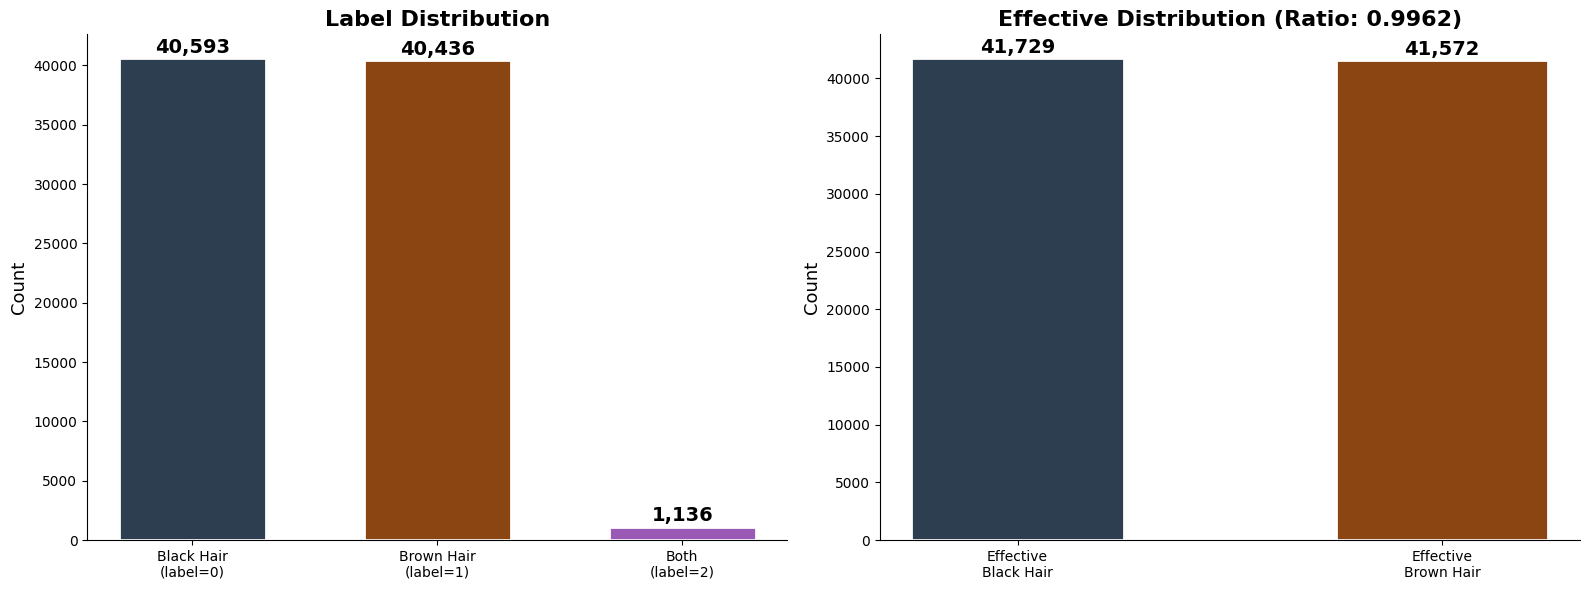

 Saved: /kaggle/working/label_distribution.png

 Pixel Statistics (first 5 batches)
  Mean (R, G, B): (0.4819, 0.3980, 0.3571)
  Std  (R, G, B): (0.3124, 0.2885, 0.2867)

 Image Specifications:
  Shape      : torch.Size([256, 3, 128, 128])
  Resolution : 128×128
  Channels   : 3
  Dtype      : torch.float32
  Range(norm): [-1.00, 1.00]

gan preprocess is done


In [7]:
# ====================================================================
# ====================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

categories = ['Black Hair\n(label=0)', 'Brown Hair\n(label=1)', 'Both\n(label=2)']
counts = [lc.get(0, 0), lc.get(1, 0), lc.get(2, 0)]
colors = ['#2C3E50', '#8B4513', '#9B59B6']

bars = axes[0].bar(categories, counts, color=colors, edgecolor='white', linewidth=2, width=0.6)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=14)
axes[0].set_title('Label Distribution', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=13)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

eff_cats = ['Effective\nBlack Hair', 'Effective\nBrown Hair']
eff_counts = [final_black, final_brown]
eff_colors = ['#2C3E50', '#8B4513']

bars2 = axes[1].bar(eff_cats, eff_counts, color=eff_colors, edgecolor='white', linewidth=2, width=0.5)
for bar, count in zip(bars2, eff_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=14)
axes[1].set_title(f'Effective Distribution (Ratio: {ratio:.4f})', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=13)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'label_distribution.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" Saved: {save_path}")

print("\n" + "=" * 60)
print(" Pixel Statistics (first 5 batches)")
print("=" * 60)

pixel_sum = torch.zeros(3)
pixel_sq_sum = torch.zeros(3)
total_pixels = 0

for batch_idx, (imgs, _) in enumerate(train_loader):
    if batch_idx >= 5:
        break
    imgs_dn = denormalize(imgs)
    pixel_sum += imgs_dn.sum(dim=[0, 2, 3]).cpu()
    pixel_sq_sum += (imgs_dn ** 2).sum(dim=[0, 2, 3]).cpu()
    total_pixels += imgs.shape[0] * imgs.shape[2] * imgs.shape[3]

mean = pixel_sum / total_pixels
std = torch.sqrt(pixel_sq_sum / total_pixels - mean ** 2)

print(f"  Mean (R, G, B): ({mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f})")
print(f"  Std  (R, G, B): ({std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f})")

sample_imgs, _ = next(iter(train_loader))
print(f"\n Image Specifications:")
print(f"  Shape      : {sample_imgs.shape}")
print(f"  Resolution : {sample_imgs.shape[2]}×{sample_imgs.shape[3]}")
print(f"  Channels   : {sample_imgs.shape[1]}")
print(f"  Dtype      : {sample_imgs.dtype}")
print(f"  Range(norm): [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]")

print("\n" + "=" * 60)
print("gan preprocess is done")
print("=" * 60)


In [8]:
# ====================================================================
# Cell 2: Fast StyleGAN-Lite Architecture (128×128 Unconditional)
# ====================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ====================== CONFIG ======================
CONFIG = {
    'nz': 256,              # Latent z dimension
    'w_dim': 256,            # Style vector w dimension
    'mapping_layers': 4,     # Mapping network depth (lite: 4 instead of 8)
    'ngf': 64,               # Generator base features
    'ndf': 64,               # Discriminator base features
    'nc': 3,                 # Image channels
    'image_size': IMAGE_SIZE,  # 128 (from Cell 1)

    # Training
    'batch_size': BATCH_SIZE,  # 256 (from Cell 1)
    'num_epochs': 10,
    'lr_g': 0.0002,
    'lr_d': 0.0004,           # TTUR: D learns faster
    'beta1': 0.0,             # StyleGAN convention
    'beta2': 0.99,

    # Loss
    'loss_type': 'bce',
    'label_smooth_real': 0.9,
    'label_smooth_fake': 0.0,

    # Eval
    'fid_sample_size': 1024,
    'fid_interval': 5,
    'sample_interval': 5,

    # Paths
    'save_dir': '/kaggle/working/stylegan_lite/checkpoints',
    'sample_dir': '/kaggle/working/stylegan_lite/samples',
}

os.makedirs(CONFIG['save_dir'], exist_ok=True)
os.makedirs(CONFIG['sample_dir'], exist_ok=True)

# ====================== Weight Init ======================
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 and hasattr(m, 'weight'):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1 and hasattr(m, 'weight'):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1 and hasattr(m, 'weight'):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

# ====================== Pixel Norm ======================
class PixelNorm(nn.Module):
    """Normalize each pixel across channels (used in Mapping Network)."""
    def forward(self, x):
        return x / (torch.mean(x ** 2, dim=1, keepdim=True).sqrt() + 1e-8)

# ====================== AdaIN ======================
class AdaIN(nn.Module):
    """Adaptive Instance Normalization — core of style injection."""
    def __init__(self, channels, w_dim):
        super().__init__()
        self.instance_norm = nn.InstanceNorm2d(channels)
        self.style_scale = nn.Linear(w_dim, channels)
        self.style_bias = nn.Linear(w_dim, channels)
        # Initialize to identity transform
        nn.init.ones_(self.style_scale.weight)
        nn.init.zeros_(self.style_scale.bias)
        nn.init.zeros_(self.style_bias.weight)
        nn.init.zeros_(self.style_bias.bias)

    def forward(self, x, w):
        x = self.instance_norm(x)
        scale = self.style_scale(w).unsqueeze(2).unsqueeze(3)  # (B, C, 1, 1)
        bias = self.style_bias(w).unsqueeze(2).unsqueeze(3)
        return scale * x + bias

# ====================== Noise Injection ======================
class NoiseInjection(nn.Module):
    """Per-pixel noise injection (adds stochastic detail)."""
    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(1, channels, 1, 1))

    def forward(self, x):
        noise = torch.randn(x.size(0), 1, x.size(2), x.size(3), device=x.device)
        return x + self.weight * noise

# ====================== Style Block ======================
class StyleBlock(nn.Module):
    """One block: Upsample → Conv → Noise → AdaIN → LeakyReLU."""
    def __init__(self, in_ch, out_ch, w_dim, upsample=True):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear',
                                     align_corners=False) if upsample else None
        self.conv = nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False)
        self.noise = NoiseInjection(out_ch)
        self.adain = AdaIN(out_ch, w_dim)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, w):
        if self.upsample is not None:
            x = self.upsample(x)
        x = self.conv(x)
        x = self.noise(x)
        x = self.adain(x, w)
        x = self.act(x)
        return x

# ====================== Mapping Network ======================
class MappingNetwork(nn.Module):
    """z → w mapping (4 layers for Lite version)."""
    def __init__(self, z_dim, w_dim, num_layers=4):
        super().__init__()
        layers = [PixelNorm()]
        for i in range(num_layers):
            in_d = z_dim if i == 0 else w_dim
            layers.append(nn.Linear(in_d, w_dim))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

# ====================== Generator ======================
class Generator(nn.Module):
    """
    Fast StyleGAN-Lite Generator for 128×128.

    Architecture:
        Learned Constant 4×4 (ngf*8 channels)
        StyleBlock: 4×4   → 8×8    (ngf*8 → ngf*4)
        StyleBlock: 8×8   → 16×16  (ngf*4 → ngf*2)
        StyleBlock: 16×16 → 32×32  (ngf*2 → ngf)
        StyleBlock: 32×32 → 64×64  (ngf   → ngf//2)
        StyleBlock: 64×64 → 128×128(ngf//2 → ngf//4)
        ToRGB:     1×1 Conv → 3 channels
    """
    def __init__(self, nz, w_dim, ngf, nc, mapping_layers=4):
        super().__init__()

        self.mapping = MappingNetwork(nz, w_dim, mapping_layers)

        # Learned constant input: (ngf*8) × 4 × 4
        self.constant = nn.Parameter(torch.randn(1, ngf * 8, 4, 4))

        # Initial processing on 4×4 (no upsample)
        self.style0 = StyleBlock(ngf * 8, ngf * 8, w_dim, upsample=False)

        # Upsample blocks: 4→8→16→32→64→128
        self.style1 = StyleBlock(ngf * 8, ngf * 4, w_dim, upsample=True)   # 4→8
        self.style2 = StyleBlock(ngf * 4, ngf * 2, w_dim, upsample=True)   # 8→16
        self.style3 = StyleBlock(ngf * 2, ngf,     w_dim, upsample=True)   # 16→32
        self.style4 = StyleBlock(ngf,     ngf // 2, w_dim, upsample=True)  # 32→64
        self.style5 = StyleBlock(ngf // 2, ngf // 4, w_dim, upsample=True) # 64→128

        # To RGB
        self.to_rgb = nn.Sequential(
            nn.Conv2d(ngf // 4, nc, 1, 1, 0),
            nn.Tanh()
        )

    def forward(self, z):
        # z: (B, nz) — flat vector
        w = self.mapping(z)                        # (B, w_dim)

        # Start from learned constant
        x = self.constant.expand(z.size(0), -1, -1, -1)  # (B, ngf*8, 4, 4)

        x = self.style0(x, w)   # 4×4
        x = self.style1(x, w)   # 8×8
        x = self.style2(x, w)   # 16×16
        x = self.style3(x, w)   # 32×32
        x = self.style4(x, w)   # 64×64
        x = self.style5(x, w)   # 128×128

        return self.to_rgb(x)   # (B, 3, 128, 128)

# ====================== Discriminator ======================
class Discriminator(nn.Module):
    """
    Discriminator for 128×128 (Enhanced DCGAN-style).

    128×128 → 64×64 → 32×32 → 16×16 → 8×8 → 4×4 → 1
    """
    def __init__(self, nc, ndf):
        super().__init__()

        self.features = nn.Sequential(
            # (3 × 128 × 128) → (ndf//2 × 64 × 64)
            nn.Conv2d(nc, ndf // 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # → (ndf × 32 × 32)
            nn.Conv2d(ndf // 2, ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf),
            nn.LeakyReLU(0.2, inplace=True),

            # → (ndf*2 × 16 × 16)
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # → (ndf*4 × 8 × 8)
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # → (ndf*8 × 4 × 4)
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        features = self.features(img)
        output = self.classifier(features)
        return output.view(-1)

    def extract_features(self, img):
        return self.features(img).view(img.size(0), -1)

# ====================== Instantiate ======================
netG = Generator(CONFIG['nz'], CONFIG['w_dim'], CONFIG['ngf'],
                 CONFIG['nc'], CONFIG['mapping_layers']).to(DEVICE)
netD = Discriminator(CONFIG['nc'], CONFIG['ndf']).to(DEVICE)

# Apply weight init (skip mapping network & adain for better stability)
netD.apply(weights_init)

# For Generator: only init conv layers, not mapping/adain
for name, module in netG.named_modules():
    if isinstance(module, nn.Conv2d) and 'to_rgb' not in name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)

# ====================== Print Stats ======================
total_G = sum(p.numel() for p in netG.parameters())
total_D = sum(p.numel() for p in netD.parameters())

print("=" * 60)
print("  GENERATOR (StyleGAN-Lite)")
print("=" * 60)
print(f"  Mapping Network: z({CONFIG['nz']}) → w({CONFIG['w_dim']}) × {CONFIG['mapping_layers']} layers")
print(f"  Synthesis: Constant 4×4 → 5 StyleBlocks → 128×128")
print(f"  Key features: AdaIN, Noise Injection, Learned Constant")
print(f"\n  Parameters: {total_G:,}")

print("\n" + "=" * 60)
print("  DISCRIMINATOR")
print("=" * 60)
print(f"  128×128 → 5 Conv layers → 1")
print(f"\n  Parameters: {total_D:,}")

print(f"\n{'='*60}")
print(f"  TOTAL PARAMETERS: {total_G + total_D:,}")
print(f"{'='*60}")

# ====================== Verify ======================
with torch.no_grad():
    test_z = torch.randn(2, CONFIG['nz'], device=DEVICE)   # Flat z (not 4D!)
    test_img = netG(test_z)
    test_out = netD(test_img)

print(f"\n  Shape check:")
print(f"    z      → {test_z.shape}")
print(f"    G(z)   → {test_img.shape}")
print(f"    D(G(z))→ {test_out.shape}")
print(f"    Scores : {test_out.data.cpu().numpy()}")

# Fixed noise for visualization (flat vector for StyleGAN-Lite)
fixed_noise = torch.randn(64, CONFIG['nz'], device=DEVICE)

print(f"\n✓ StyleGAN-Lite Architecture ready!")
print(f"  Fixed noise shape: {fixed_noise.shape}")


  GENERATOR (StyleGAN-Lite)
  Mapping Network: z(256) → w(256) × 4 layers
  Synthesis: Constant 4×4 → 5 StyleBlocks → 128×128
  Key features: AdaIN, Noise Injection, Learned Constant

  Parameters: 4,721,155

  DISCRIMINATOR
  128×128 → 5 Conv layers → 1

  Parameters: 2,796,928

  TOTAL PARAMETERS: 7,518,083

  Shape check:
    z      → torch.Size([2, 256])
    G(z)   → torch.Size([2, 3, 128, 128])
    D(G(z))→ torch.Size([2])
    Scores : [0.81132156 0.823012  ]

✓ StyleGAN-Lite Architecture ready!
  Fixed noise shape: torch.Size([64, 256])


In [9]:
# ====================================================================
# Cell 3: Loss, Optimizers & FID
# ====================================================================
import torch.optim as optim
from scipy import linalg

# ====================== Optimizers (TTUR) ======================
optimizerG = optim.Adam(netG.parameters(), lr=CONFIG['lr_g'],
                         betas=(CONFIG['beta1'], CONFIG['beta2']))
optimizerD = optim.Adam(netD.parameters(), lr=CONFIG['lr_d'],
                         betas=(CONFIG['beta1'], CONFIG['beta2']))

print(f"  Optimizer G: Adam(lr={CONFIG['lr_g']}, betas=({CONFIG['beta1']}, {CONFIG['beta2']}))")
print(f"  Optimizer D: Adam(lr={CONFIG['lr_d']}, betas=({CONFIG['beta1']}, {CONFIG['beta2']}))")
print(f"  TTUR: lr_D / lr_G = {CONFIG['lr_d']/CONFIG['lr_g']:.1f}x")

# ====================== Loss ======================
criterion = nn.BCELoss()
print(f"  Loss: BCE (Standard Minimax)")

# ====================== FID Calculator ======================
from torchvision.models import inception_v3

class FIDCalculator:
    def __init__(self, device, batch_size=64):
        self.device = device
        self.batch_size = batch_size
        self.inception = None
        self._loaded = False

    def _load_model(self):
        if self._loaded:
            return
        print("    Loading InceptionV3...")
        self.inception = inception_v3(weights='IMAGENET1K_V1',
                                       transform_input=False)
        self.inception.fc = nn.Identity()
        self.inception.to(self.device)
        self.inception.eval()
        self._loaded = True

    @torch.no_grad()
    def _get_features(self, images):
        imgs = F.interpolate(images, size=(299, 299),
                              mode='bilinear', align_corners=False)
        mean = torch.tensor([0.485, 0.456, 0.406],
                             device=self.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225],
                            device=self.device).view(1, 3, 1, 1)
        imgs = (imgs - mean) / std
        return self.inception(imgs).cpu().numpy()

    @torch.no_grad()
    def compute_stats(self, dataloader, max_samples=1024):
        self._load_model()
        all_feats = []
        count = 0
        for images, _ in dataloader:
            if count >= max_samples:
                break
            images = images.to(self.device) * 0.5 + 0.5
            feats = self._get_features(images)
            all_feats.append(feats)
            count += feats.shape[0]
            if count % 256 == 0:
                print(f"    Real features: {count}/{max_samples}")

        all_feats = np.concatenate(all_feats)[:max_samples]
        return np.mean(all_feats, axis=0), np.cov(all_feats, rowvar=False)

    @torch.no_grad()
    def compute_fid(self, generator, real_mu, real_sigma, nz, num_samples=1024):
        self._load_model()
        generator.eval()
        all_feats = []
        remaining = num_samples

        while remaining > 0:
            batch = min(self.batch_size, remaining)
            # StyleGAN-Lite uses flat z vector
            noise = torch.randn(batch, nz, device=self.device)
            fake = generator(noise)
            fake = torch.clamp(fake * 0.5 + 0.5, 0, 1)
            feats = self._get_features(fake)
            all_feats.append(feats)
            remaining -= batch

        generator.train()
        all_feats = np.concatenate(all_feats)[:num_samples]
        gen_mu = np.mean(all_feats, axis=0)
        gen_sigma = np.cov(all_feats, rowvar=False)
        return self._frechet_dist(real_mu, real_sigma, gen_mu, gen_sigma)

    def unload_model(self):
        if self._loaded:
            del self.inception
            self.inception = None
            self._loaded = False
            torch.cuda.empty_cache()
            print("    InceptionV3 unloaded from GPU.")

    @staticmethod
    def _frechet_dist(mu1, s1, mu2, s2):
        diff = mu1 - mu2
        covmean, _ = linalg.sqrtm(s1.dot(s2), disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        return float(diff.dot(diff) + np.trace(s1) + np.trace(s2)
                      - 2 * np.trace(covmean))

# ====================== Compute Real Stats ======================
import time as _time

fid_calculator = FIDCalculator(DEVICE, batch_size=64)

print("\nComputing real data statistics for FID...")
_t = _time.time()
real_mu, real_sigma = fid_calculator.compute_stats(
    train_loader, max_samples=CONFIG['fid_sample_size']
)
print(f"Done in {_time.time()-_t:.1f}s | mu: {real_mu.shape}, sigma: {real_sigma.shape}")

fid_calculator.unload_model()
print("\n✓ FID setup complete! Ready for training.")


  Optimizer G: Adam(lr=0.0002, betas=(0.0, 0.99))
  Optimizer D: Adam(lr=0.0004, betas=(0.0, 0.99))
  TTUR: lr_D / lr_G = 2.0x
  Loss: BCE (Standard Minimax)

Computing real data statistics for FID...
    Loading InceptionV3...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 156MB/s]  


    Real features: 256/1024
    Real features: 512/1024
    Real features: 768/1024
    Real features: 1024/1024
Done in 11.4s | mu: (2048,), sigma: (2048, 2048)
    InceptionV3 unloaded from GPU.

✓ FID setup complete! Ready for training.


In [10]:
# ====================================================================
# Cell 4: Training Loop — StyleGAN-Lite
# ====================================================================
import time
import torchvision.utils as vutils

# ====================== Setup ======================
G_losses = []
D_losses = []
fid_scores = []
fid_epochs = []
iters = 0

print("=" * 60)
print(f"  🚀 STYLEGAN-LITE TRAINING — {CONFIG['num_epochs']} Epochs")
print(f"  Device: {DEVICE} | Batch Size: {CONFIG['batch_size']}")
print(f"  Generator: StyleGAN-Lite | Discriminator: Enhanced DCGAN")
print(f"  TTUR: lr_G={CONFIG['lr_g']} | lr_D={CONFIG['lr_d']}")
print(f"  Images per Epoch: ~{len(train_loader) * CONFIG['batch_size']:,}")
print("=" * 60)

total_start = time.time()

for epoch in range(1, CONFIG['num_epochs'] + 1):
    epoch_start = time.time()

    netD.train()
    netG.train()

    epoch_D_loss = 0.0
    epoch_G_loss = 0.0
    num_batches = 0

    for i, data in enumerate(train_loader, 0):
        # -----------------------------------------------------------
        # (1) Update Discriminator
        # -----------------------------------------------------------
        netD.zero_grad()

        ## Real batch
        real_cpu = data[0].to(DEVICE)
        b_size = real_cpu.size(0)

        label_real = torch.full((b_size,), CONFIG['label_smooth_real'],
                                 dtype=torch.float, device=DEVICE)

        output_real = netD(real_cpu)
        errD_real = criterion(output_real, label_real)
        errD_real.backward()
        D_x = output_real.mean().item()

        ## Fake batch
        noise = torch.randn(b_size, CONFIG['nz'], device=DEVICE)
        fake = netG(noise)

        label_fake = torch.full((b_size,), CONFIG['label_smooth_fake'],
                                 dtype=torch.float, device=DEVICE)

        output_fake = netD(fake.detach())
        errD_fake = criterion(output_fake, label_fake)
        errD_fake.backward()
        D_G_z1 = output_fake.mean().item()

        errD = errD_real + errD_fake
        optimizerD.step()

        # -----------------------------------------------------------
        # (2) Update Generator
        # -----------------------------------------------------------
        netG.zero_grad()

        label_g = torch.full((b_size,), 1.0, dtype=torch.float, device=DEVICE)
        output_g = netD(fake)
        errG = criterion(output_g, label_g)
        errG.backward()
        D_G_z2 = output_g.mean().item()
        optimizerG.step()

        # -----------------------------------------------------------
        # (3) Logging
        # -----------------------------------------------------------
        G_losses.append(errG.item())
        D_losses.append(errD.item())
        epoch_D_loss += errD.item()
        epoch_G_loss += errG.item()
        num_batches += 1

        if i % 50 == 0:
            print(f"  [{epoch}/{CONFIG['num_epochs']}][{i}/{len(train_loader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} "
                  f"D(x): {D_x:.2f} D(G(z)): {D_G_z1:.2f}/{D_G_z2:.2f}",
                  flush=True)

        # Cleanup
        del real_cpu, noise, fake, output_real, output_fake, output_g
        del errD_real, errD_fake, errD, errG
        iters += 1

    # ==================== End of Epoch ====================
    epoch_time = time.time() - epoch_start
    avg_D = epoch_D_loss / num_batches
    avg_G = epoch_G_loss / num_batches

    print(f"\n  Epoch {epoch}/{CONFIG['num_epochs']} — {epoch_time:.0f}s "
          f"| Avg D_loss: {avg_D:.4f} | Avg G_loss: {avg_G:.4f}")

    # --- Save Samples ---
    if (epoch % CONFIG['sample_interval'] == 0) or (epoch == CONFIG['num_epochs']):
        with torch.no_grad():
            netG.eval()
            fake_samples = netG(fixed_noise).detach().cpu()
            netG.train()
        vutils.save_image(fake_samples,
                          f"{CONFIG['sample_dir']}/fake_epoch_{epoch:03d}.png",
                          normalize=True, nrow=8)
        print(f"  📸 Saved samples for epoch {epoch}")

    # --- Compute FID ---
    if (epoch % CONFIG['fid_interval'] == 0) or (epoch == CONFIG['num_epochs']):
        print(f"  📊 Computing FID for epoch {epoch}...")
        fid_t = time.time()
        fid_val = fid_calculator.compute_fid(
            netG, real_mu, real_sigma,
            CONFIG['nz'], num_samples=CONFIG['fid_sample_size']
        )
        fid_scores.append(fid_val)
        fid_epochs.append(epoch)
        fid_calculator.unload_model()
        print(f"  ✅ FID @ Epoch {epoch}: {fid_val:.1f} ({time.time()-fid_t:.0f}s)")

    # --- Save Checkpoint ---
    if (epoch % 5 == 0) or (epoch == CONFIG['num_epochs']):
        ckpt_path = f"{CONFIG['save_dir']}/ckpt_epoch_{epoch:03d}.pt"
        torch.save({
            'epoch': epoch,
            'netG_state_dict': netG.state_dict(),
            'netD_state_dict': netD.state_dict(),
            'optimizerG_state_dict': optimizerG.state_dict(),
            'optimizerD_state_dict': optimizerD.state_dict(),
            'G_losses': G_losses,
            'D_losses': D_losses,
            'fid_scores': fid_scores,
            'fid_epochs': fid_epochs,
            'config': CONFIG,
        }, ckpt_path)
        print(f"  💾 Saved checkpoint: {ckpt_path}")

    print()

# ====================== Training Complete ======================
total_time = time.time() - total_start
print("=" * 60)
print(f"   TRAINING COMPLETE!")
print(f"  Total time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")
print(f"  Total iterations: {iters:,}")
if fid_scores:
    print(f"  Best FID: {min(fid_scores):.1f} @ Epoch {fid_epochs[fid_scores.index(min(fid_scores))]}")
    print(f"  Final FID: {fid_scores[-1]:.1f}")
print("=" * 60)


  🚀 STYLEGAN-LITE TRAINING — 10 Epochs
  Device: cuda | Batch Size: 256
  Generator: StyleGAN-Lite | Discriminator: Enhanced DCGAN
  TTUR: lr_G=0.0002 | lr_D=0.0004
  Images per Epoch: ~81,920
  [1/10][0/320] Loss_D: 2.4148 Loss_G: 36.3197 D(x): 0.55 D(G(z)): 0.81/0.00
  [1/10][50/320] Loss_D: 2.7914 Loss_G: 10.9995 D(x): 0.34 D(G(z)): 0.01/0.03
  [1/10][100/320] Loss_D: 0.6404 Loss_G: 5.9598 D(x): 0.91 D(G(z)): 0.15/0.02
  [1/10][150/320] Loss_D: 0.6986 Loss_G: 3.8140 D(x): 0.67 D(G(z)): 0.05/0.07
  [1/10][200/320] Loss_D: 2.5532 Loss_G: 13.9271 D(x): 0.29 D(G(z)): 0.00/0.00
  [1/10][250/320] Loss_D: 0.9751 Loss_G: 4.8802 D(x): 0.54 D(G(z)): 0.00/0.01
  [1/10][300/320] Loss_D: 0.7846 Loss_G: 11.7934 D(x): 0.97 D(G(z)): 0.25/0.00

  Epoch 1/10 — 158s | Avg D_loss: 1.3248 | Avg G_loss: 9.7386

  [2/10][0/320] Loss_D: 0.5020 Loss_G: 4.0643 D(x): 0.91 D(G(z)): 0.07/0.03
  [2/10][50/320] Loss_D: 0.5212 Loss_G: 3.0948 D(x): 0.95 D(G(z)): 0.11/0.05
  [2/10][100/320] Loss_D: 0.4013 Loss_G: 5.